# Week 5: Advanced Machine Learning

## AnalystLab Africa Data Science Internship

### Project Overview

This project explores advanced machine learning techniques for predicting house prices using the Housing Dataset. The aim is to compare multiple regression algorithms, improve model performance through hyperparameter tuning, and identify the best-performing model.

The project includes:

* Data preprocessing
* Baseline Linear Regression model
* Decision Tree Regressor
* Random Forest Regressor
* Gradient Boosting Regressor
* Hyperparameter tuning using GridSearchCV
* Performance comparison
* Model evaluation
* Conclusions and recommendations

### Objectives

* Build multiple regression models.
* Compare their predictive performance.
* Improve model accuracy through hyperparameter tuning.
* Identify the best-performing model based on evaluation metrics.


Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

Load Dataset

In [2]:
housing = pd.read_csv("Housing.csv")

housing.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


Dataset Inspection

In [3]:
print(housing.shape)

housing.info()

housing.isnull().sum()

(545, 13)
<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

Encode Categorical Variables

In [4]:
housing = pd.get_dummies(
    housing,
    drop_first=True
)

housing.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


Features and Target

In [5]:
X = housing.drop("price", axis=1)

y = housing["price"]

Feature Scaling

In [6]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

Train-Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(436, 13)
(109, 13)


Train the Baseline Model

In [8]:
# Build the baseline Linear Regression model
baseline_model = LinearRegression()

baseline_model.fit(X_train, y_train)

print("Baseline Linear Regression model trained successfully!")

Baseline Linear Regression model trained successfully!


Make Predictions

In [9]:
# Predict house prices
y_pred_baseline = baseline_model.predict(X_test)

print(y_pred_baseline[:10])

[5164653.90033967 7224722.29802166 3109863.24240338 4612075.3272256
 3294646.25725956 3532275.09556558 5611774.56836474 6368145.98732718
 2722856.95689986 2629405.61585784]


Evaluate the Baseline Model

In [10]:
# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred_baseline)
mse = mean_squared_error(y_test, y_pred_baseline)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_baseline)

print("Baseline Linear Regression Performance")
print("--------------------------------------")
print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

Baseline Linear Regression Performance
--------------------------------------
MAE  : 970043.40
MSE  : 1754318687330.67
RMSE : 1324506.96
R²   : 0.6529


Visualize Predictions

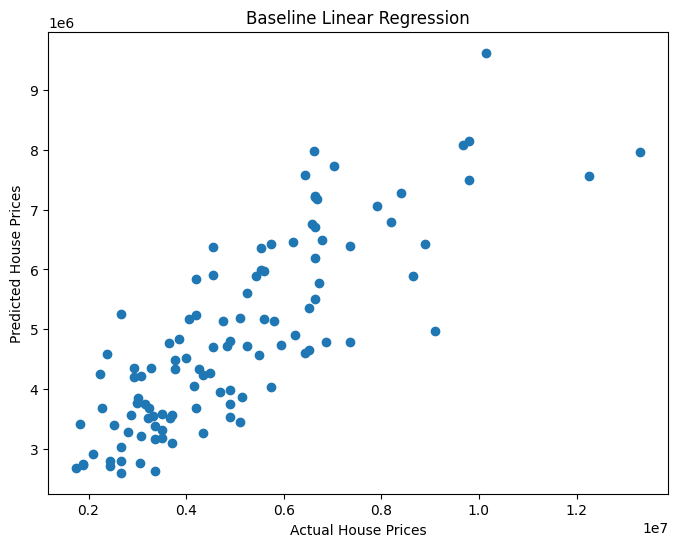

In [11]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred_baseline)

plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Baseline Linear Regression")

plt.show()

Train the Model

In [12]:
# Import Decision Tree Regressor
from sklearn.tree import DecisionTreeRegressor

# Create the model
dt_model = DecisionTreeRegressor(random_state=42)

# Train the model
dt_model.fit(X_train, y_train)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


Make Predictions

In [13]:
# Predict house prices
dt_predictions = dt_model.predict(X_test)

print(dt_predictions[:10])

[5600000. 7840000. 3850000. 4935000. 2660000. 2730000. 6090000. 4893000.
 2100000. 2940000.]


Evaluate the Model

In [14]:
dt_mae = mean_absolute_error(y_test, dt_predictions)
dt_mse = mean_squared_error(y_test, dt_predictions)
dt_rmse = np.sqrt(dt_mse)
dt_r2 = r2_score(y_test, dt_predictions)

print("Decision Tree Performance")
print("-------------------------")
print(f"MAE  : {dt_mae:.2f}")
print(f"MSE  : {dt_mse:.2f}")
print(f"RMSE : {dt_rmse:.2f}")
print(f"R²   : {dt_r2:.4f}")

Decision Tree Performance
-------------------------
MAE  : 1195266.06
MSE  : 2642802637614.68
RMSE : 1625669.90
R²   : 0.4771


Visualization

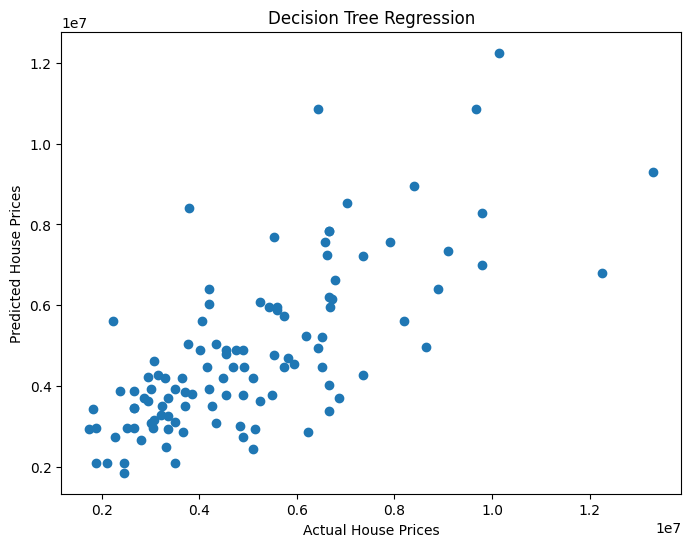

In [15]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, dt_predictions)

plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Decision Tree Regression")

plt.show()

Train the Random Forest Model

In [16]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


Make Predictions

In [17]:
rf_predictions = rf_model.predict(X_test)

print(rf_predictions[:10])

[5344780.   7287070.   3754878.75 4502120.   3748885.   3432660.
 5070240.   5032580.   2568160.   2822893.5 ]


Evaluate the Model

In [18]:
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_mse = mean_squared_error(y_test, rf_predictions)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest Performance")
print("-------------------------")
print(f"MAE  : {rf_mae:.2f}")
print(f"MSE  : {rf_mse:.2f}")
print(f"RMSE : {rf_rmse:.2f}")
print(f"R²   : {rf_r2:.4f}")

Random Forest Performance
-------------------------
MAE  : 1017470.62
MSE  : 1959406221695.99
RMSE : 1399787.92
R²   : 0.6123


Visualize the Predictions

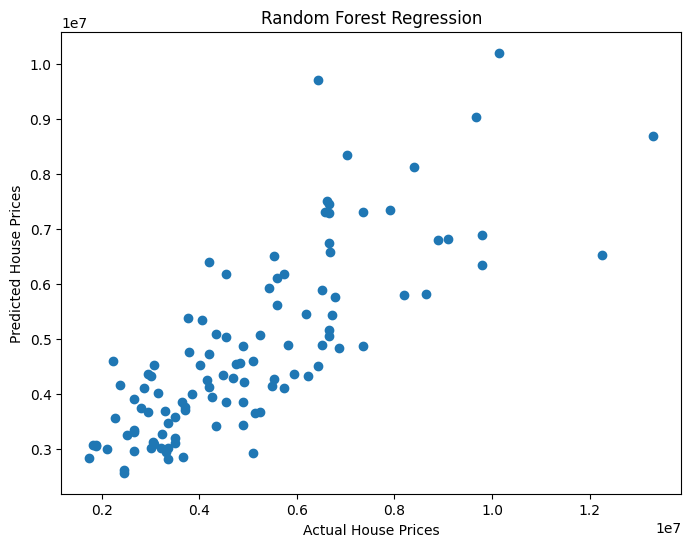

In [19]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, rf_predictions)

plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Random Forest Regression")

plt.show()

Train the Gradient Boosting Model

In [20]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    random_state=42
)

gb_model.fit(X_train, y_train)

print("Gradient Boosting model trained successfully!")

Gradient Boosting model trained successfully!


Make Predictions

In [21]:
gb_predictions = gb_model.predict(X_test)

print(gb_predictions[:10])

[4486984.35601967 7208750.95765462 3693243.50703918 4439761.73364167
 3739117.80400389 3908167.73490597 6154987.05709327 5864341.77465772
 3140942.70728673 3094515.49493127]


Evaluate the Model

In [22]:
gb_mae = mean_absolute_error(y_test, gb_predictions)
gb_mse = mean_squared_error(y_test, gb_predictions)
gb_rmse = np.sqrt(gb_mse)
gb_r2 = r2_score(y_test, gb_predictions)

print("Gradient Boosting Performance")
print("-----------------------------")
print(f"MAE  : {gb_mae:.2f}")
print(f"MSE  : {gb_mse:.2f}")
print(f"RMSE : {gb_rmse:.2f}")
print(f"R²   : {gb_r2:.4f}")

Gradient Boosting Performance
-----------------------------
MAE  : 961367.79
MSE  : 1691667619477.79
RMSE : 1300641.23
R²   : 0.6653


Visualize the Predictions

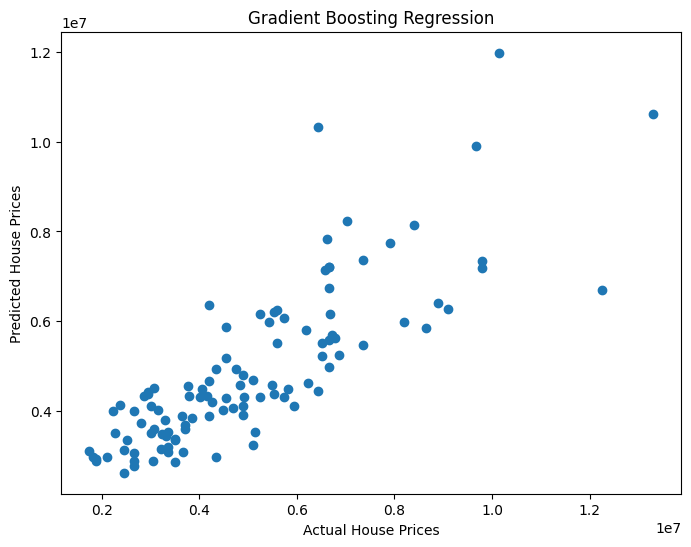

In [23]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, gb_predictions)

plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Gradient Boosting Regression")

plt.show()

Define the Parameter Grid

In [24]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3, 4]
}

Run GridSearchCV

In [25]:
grid_search = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 50}


Best Model

In [26]:
best_model = grid_search.best_estimator_

best_predictions = best_model.predict(X_test)

Evaluate the Tuned Model

In [27]:
best_mae = mean_absolute_error(y_test, best_predictions)
best_mse = mean_squared_error(y_test, best_predictions)
best_rmse = np.sqrt(best_mse)
best_r2 = r2_score(y_test, best_predictions)

print("Tuned Gradient Boosting Performance")
print("-----------------------------------")
print(f"MAE  : {best_mae:.2f}")
print(f"MSE  : {best_mse:.2f}")
print(f"RMSE : {best_rmse:.2f}")
print(f"R²   : {best_r2:.4f}")

Tuned Gradient Boosting Performance
-----------------------------------
MAE  : 1033085.83
MSE  : 1938391505155.59
RMSE : 1392261.29
R²   : 0.6165


# Conclusion

In this project, several supervised machine learning regression models were developed and compared to predict house prices using the Housing dataset.

The models included:
- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor
- Gradient Boosting Regressor
- Tuned Gradient Boosting Regressor

Among all the models evaluated, the Gradient Boosting Regressor achieved the best performance with an RMSE of 1,300,641.23 and an R² score of 0.6653. This indicates that it explained approximately 66.5% of the variation in house prices.

Hyperparameter tuning was performed using GridSearchCV. Although the best parameters were identified, the tuned model did not outperform the default Gradient Boosting model on the test dataset. This demonstrates that tuning does not always lead to better predictive performance and highlights the importance of evaluating models on unseen data.

Overall, this project strengthened my understanding of advanced machine learning algorithms, model comparison, hyperparameter tuning, and regression model evaluation.

# Recommendations

Based on the findings from this project, the following recommendations are made:

1. Use Gradient Boosting Regressor for house price prediction on this dataset due to its superior predictive performance.

2. Explore additional features such as house age, location quality, nearby amenities, and economic indicators to improve model accuracy.

3. Experiment with more advanced algorithms such as XGBoost, LightGBM, and CatBoost for potential performance improvements.

4. Perform feature selection and feature engineering to remove irrelevant variables and create more informative features.

5. Evaluate models using cross-validation and multiple evaluation metrics to ensure robust and reliable performance.